<a href="https://colab.research.google.com/github/rohit9347/DST-RECORD/blob/main/DST_exp10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mall_Customers.csv not found. Using a dummy DataFrame for demonstration.
Explained Variance Ratio: [0.6689216  0.33077843]


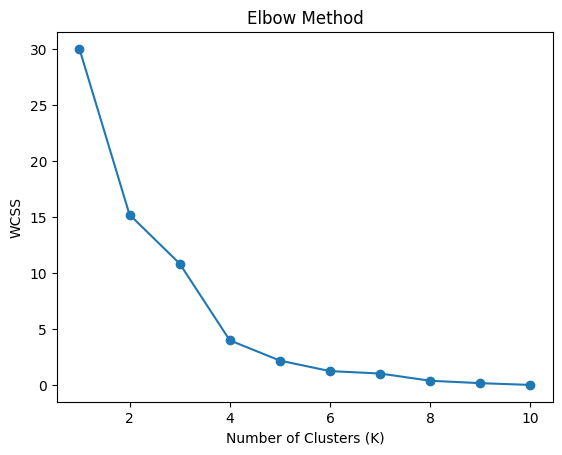

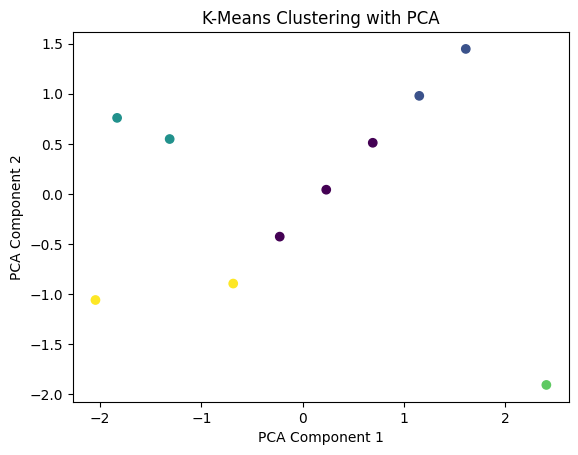

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
# Load dataset
try:
    data = pd.read_csv("Mall_Customers.csv")
except FileNotFoundError:
    print("Mall_Customers.csv not found. Using a dummy DataFrame for demonstration.")
    # Create a dummy DataFrame with similar column names for demonstration
    dummy_data = {
        'Age': [20, 25, 30, 35, 40, 45, 50, 55, 60, 65],
        'Annual Income (k$)': [15, 20, 30, 40, 50, 60, 70, 80, 90, 100],
        'Spending Score (1-100)': [39, 81, 75, 40, 50, 60, 70, 80, 90, 10]
    }
    data = pd.DataFrame(dummy_data)
# Select numerical features
X = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
# Elbow Method
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
# Plot Elbow Graph
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()
# Apply KMeans with optimal K (example K = 5
kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(X_pca)
# Plot Clusters
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("K-Means Clustering with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()